# **Flight Ticket Price Prediction Project**

In [1]:
# ==========================
# Data Manipulation
# ==========================
import pandas as pd
import numpy as np

# ==========================
# Data Visualization
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Improve plot size
plt.rcParams["figure.figsize"] = (8,5)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("flight_dataset.csv")

In [3]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [4]:
df.tail()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585
300152,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,81585


In [5]:
df.shape

(300153, 11)

In [6]:
df.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   flight            300153 non-null  str    
 2   source_city       300153 non-null  str    
 3   departure_time    300153 non-null  str    
 4   stops             300153 non-null  str    
 5   arrival_time      300153 non-null  str    
 6   destination_city  300153 non-null  str    
 7   class             300153 non-null  str    
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 25.2 MB


In [8]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [9]:
df.describe(include = "object")

C:\Users\hp\AppData\Local\Temp\ipykernel_13388\3591357663.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include = "object")


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class
count,300153,300153,300153,300153,300153,300153,300153,300153
unique,6,1561,6,6,3,6,6,2
top,Vistara,UK-706,Delhi,Morning,one,Night,Mumbai,Economy
freq,127859,3235,61343,71146,250863,91538,59097,206666


In [10]:
df.isnull().sum() 

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [11]:
(df.isnull().sum()/len(df))*100

airline             0.0
flight              0.0
source_city         0.0
departure_time      0.0
stops               0.0
arrival_time        0.0
destination_city    0.0
class               0.0
duration            0.0
days_left           0.0
price               0.0
dtype: float64

In [12]:
df.duplicated().sum() 

np.int64(0)

In [13]:
df = df.drop_duplicates() 

In [14]:
df.shape 

(300153, 11)

In [15]:
categorical_cols = df.select_dtypes(include="object").columns

numerical_cols = df.select_dtypes(exclude="object").columns

print("Categorical Features:")
print(categorical_cols)

print()

print("Numerical Features:")
print(numerical_cols) 

Categorical Features:
Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class'],
      dtype='str')

Numerical Features:
Index(['duration', 'days_left', 'price'], dtype='str')


C:\Users\hp\AppData\Local\Temp\ipykernel_13388\876354120.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [16]:
for col in categorical_cols:
    print("="*40)
    print(col)
    print(df[col].unique()) 

airline
<StringArray>
['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo', 'Air_India']
Length: 6, dtype: str
flight
<StringArray>
['SG-8709', 'SG-8157',  'I5-764',  'UK-995',  'UK-963',  'UK-945',  'UK-927',
  'UK-951',  'G8-334',  'G8-336',
 ...
  '6E-804', '6E-7183', 'SG-6017', '6E-7208', '6E-7252', '6E-7141',  '6E-557',
 '6E-7127', '6E-7259',  'AI-433']
Length: 1561, dtype: str
source_city
<StringArray>
['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
Length: 6, dtype: str
departure_time
<StringArray>
['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night', 'Late_Night']
Length: 6, dtype: str
stops
<StringArray>
['zero', 'one', 'two_or_more']
Length: 3, dtype: str
arrival_time
<StringArray>
['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening', 'Late_Night']
Length: 6, dtype: str
destination_city
<StringArray>
['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi']
Length: 6, dtype: str
class
<StringArray>
['Economy', 'Business']
Lengt

In [17]:
for col in categorical_cols:
    print(col,":",df[col].nunique())

airline : 6
flight : 1561
source_city : 6
departure_time : 6
stops : 3
arrival_time : 6
destination_city : 6
class : 2


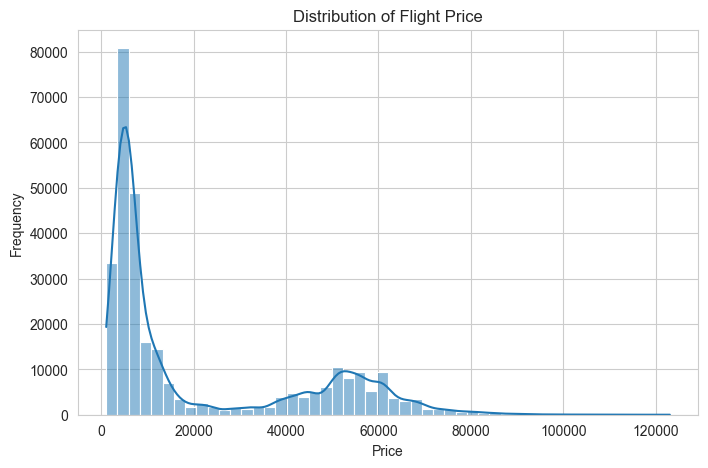

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=50, kde=True)

plt.title("Distribution of Flight Price")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show() 

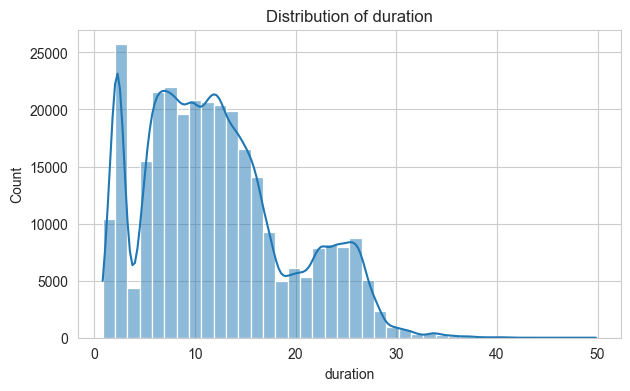

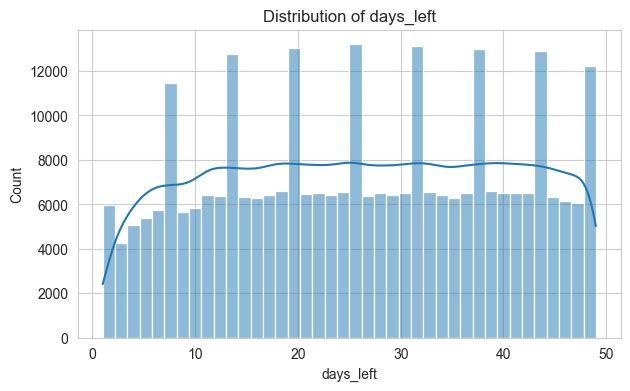

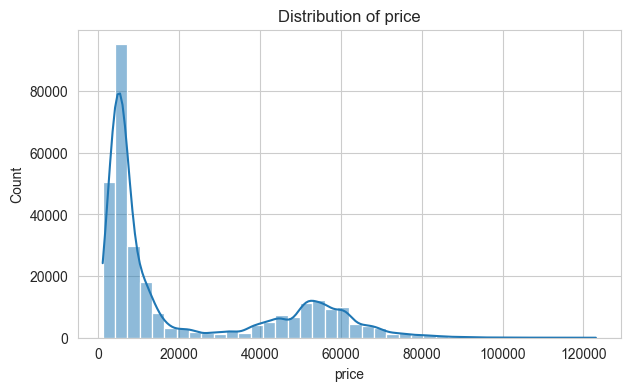

In [19]:
for col in numerical_cols:
    
    plt.figure(figsize=(7,4))
    
    sns.histplot(df[col], bins=40, kde=True)
    
    plt.title(f"Distribution of {col}")
    
    plt.show() 

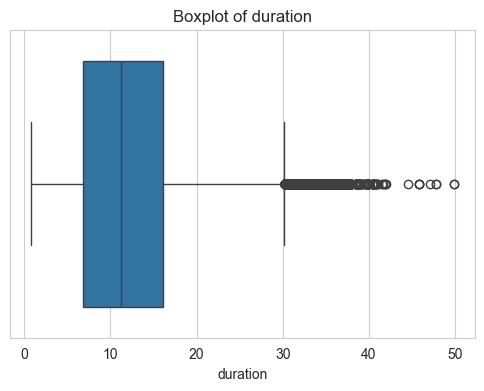

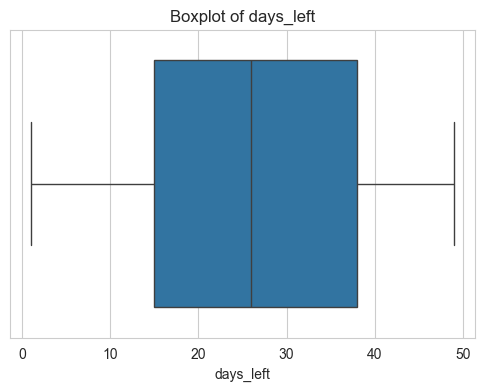

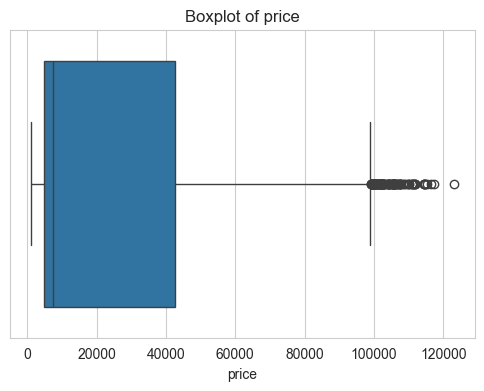

In [20]:
for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show() 

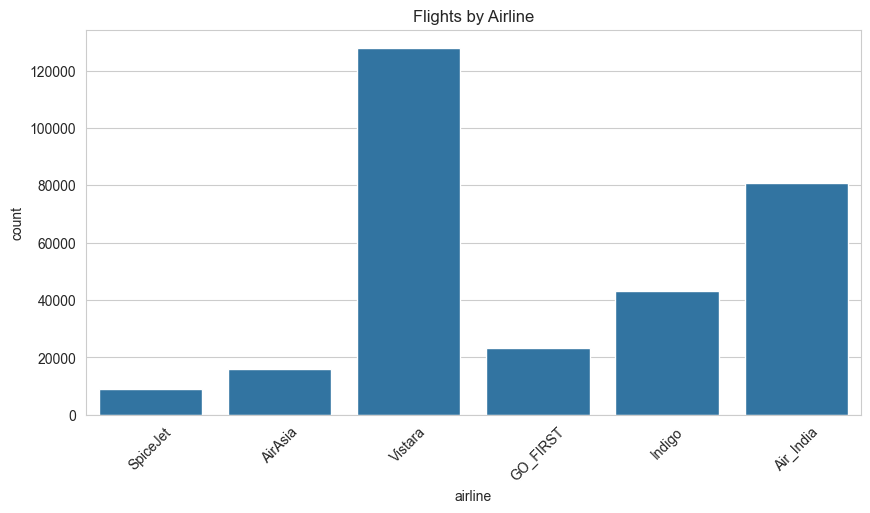

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="airline")

plt.xticks(rotation=45)

plt.title("Flights by Airline")

plt.show() 

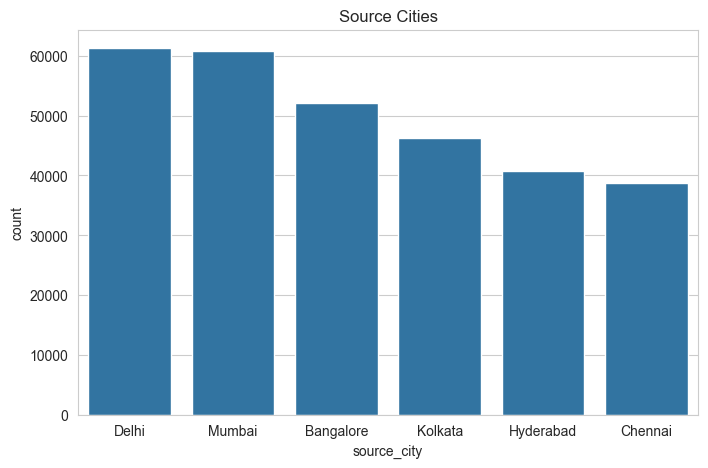

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="source_city")

plt.title("Source Cities")

plt.show() 

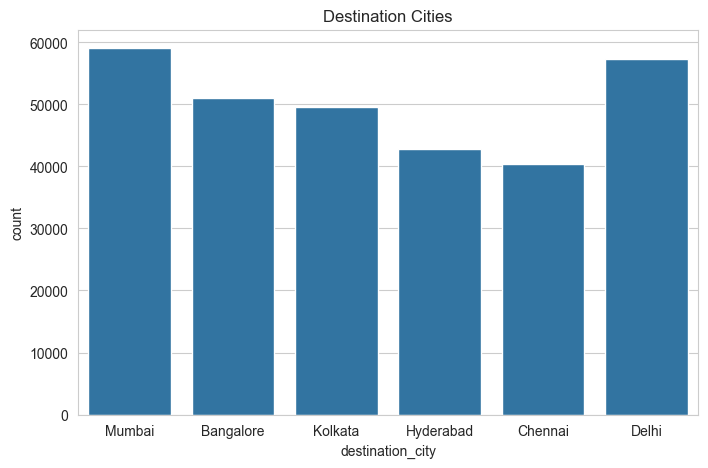

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="destination_city")

plt.title("Destination Cities")

plt.show() 

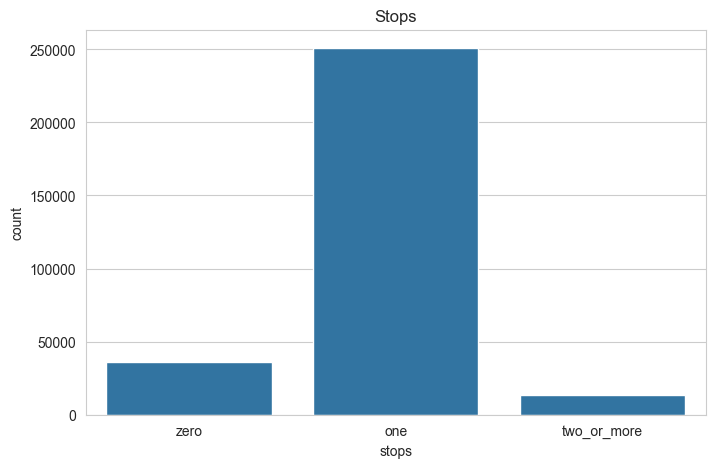

In [24]:
sns.countplot(data=df, x="stops")

plt.title("Stops")

plt.show() 

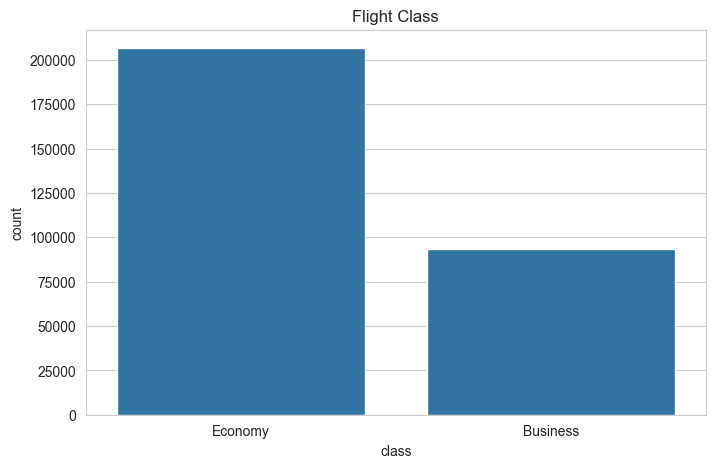

In [25]:
sns.countplot(data=df, x="class")

plt.title("Flight Class")

plt.show() 

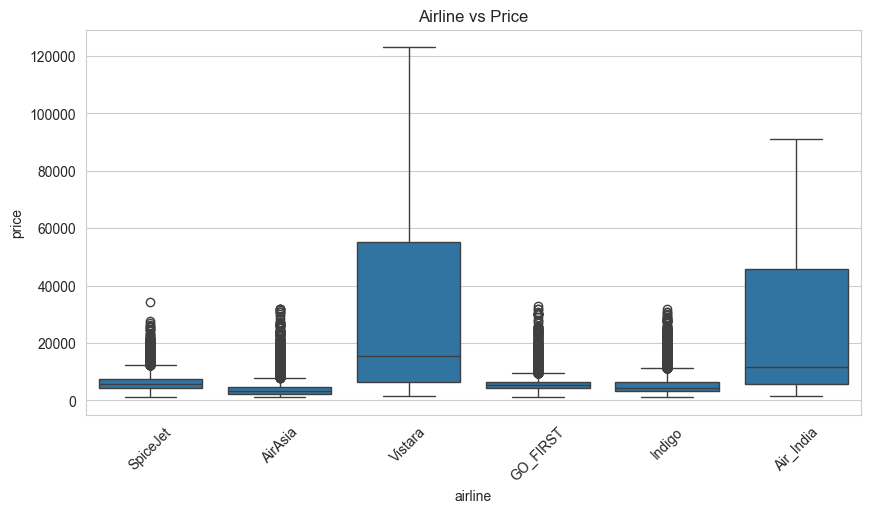

In [26]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="airline",
    y="price"
)

plt.xticks(rotation=45)

plt.title("Airline vs Price")

plt.show() 

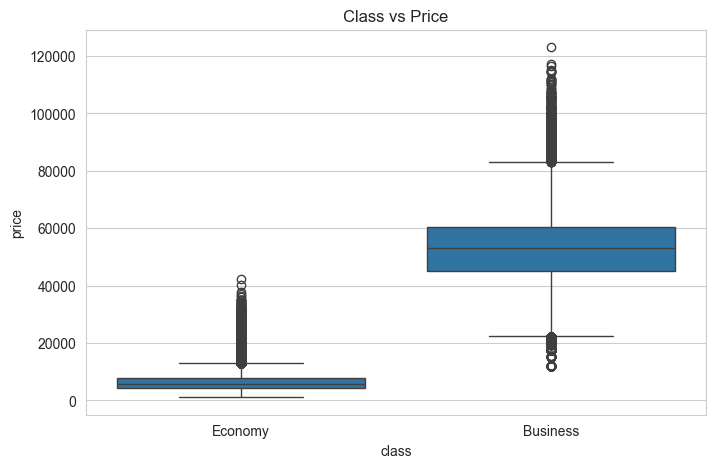

In [27]:
sns.boxplot(
    data=df,
    x="class",
    y="price"
)

plt.title("Class vs Price")

plt.show() 

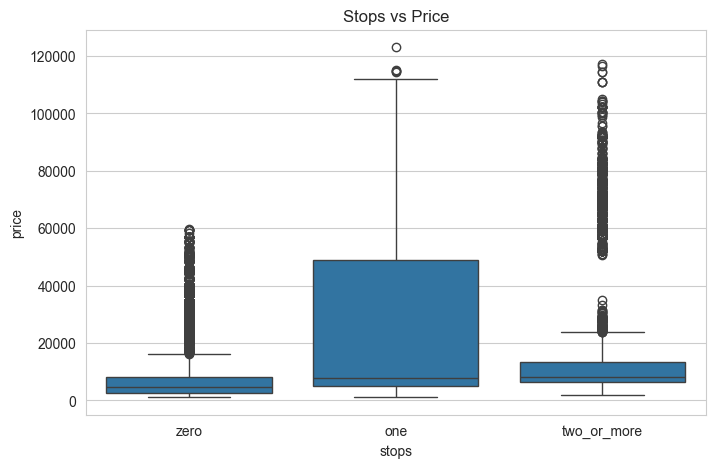

In [28]:
sns.boxplot(
    data=df,
    x="stops",
    y="price"
)

plt.title("Stops vs Price")

plt.show() 

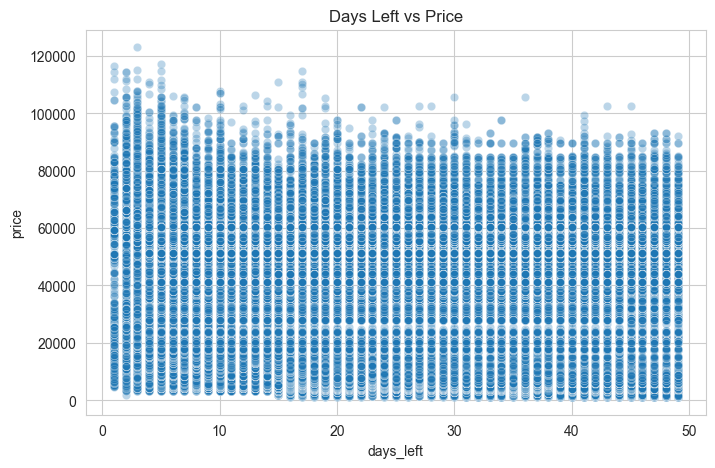

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="days_left",
    y="price",
    alpha=0.3
)

plt.title("Days Left vs Price")

plt.show() 

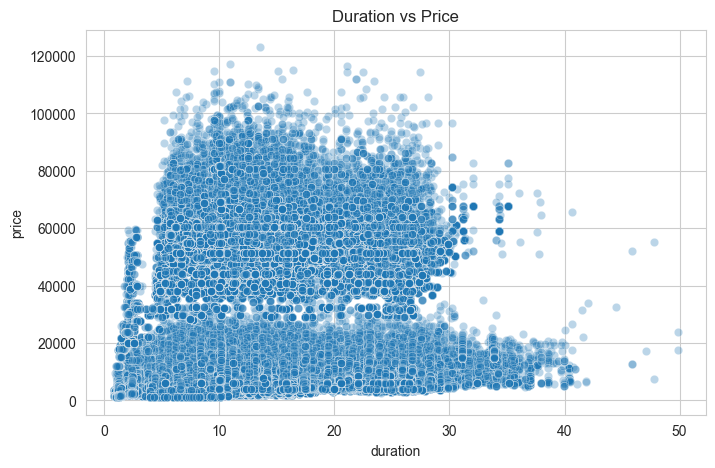

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="duration",
    y="price",
    alpha=0.3
)

plt.title("Duration vs Price")

plt.show() 

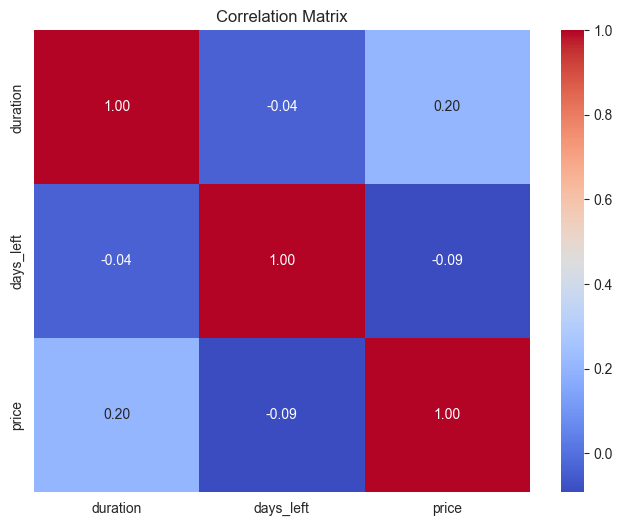

In [31]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show() 

In [32]:
for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

duration: 2110 outliers
days_left: 0 outliers
price: 123 outliers


## **Train Test Split**

In [33]:
X = df.drop("price", axis=1)

y = df["price"] 

In [34]:
print(X.shape)
print(y.shape) 

(300153, 10)
(300153,)


In [35]:
categorical_cols = X.select_dtypes(include="object").columns

numerical_cols = X.select_dtypes(exclude="object").columns

print(categorical_cols)
print(numerical_cols)

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class'],
      dtype='str')
Index(['duration', 'days_left'], dtype='str')


C:\Users\hp\AppData\Local\Temp\ipykernel_13388\3032935582.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [36]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
) 

In [37]:
X.head() 

duration  days_left  airline_Air_India  airline_GO_FIRST  airline_Indigo  \
0      2.17          1              False             False           False   
1      2.33          1              False             False           False   
2      2.17          1              False             False           False   
3      2.25          1              False             False           False   
4      2.33          1              False             False           False   

   airline_SpiceJet  airline_Vistara  flight_6E-105  flight_6E-113  \
0              True            False          False          False   
1              True            False          False          False   
2             False            False          False          False   
3             False             True          False          False   
4             False             True          False          False   

   flight_6E-121  flight_6E-123  flight_6E-126  flight_6E-128  flight_6E-131  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4          False          False          False          False          False   

   flight_6E-132  flight_6E-134  flight_6E-135  flight_6E-136  flight_6E-138  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4          False          False          False          False          False   

   flight_6E-139  flight_6E-146  flight_6E-148  flight_6E-149  flight_6E-151  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4          False          False          False          False          False   

   flight_6E-152  flight_6E-153  flight_6E-154  flight_6E-156  flight_6E-157  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4          False          False          False          False          False   

   flight_6E-161  flight_6E-164  flight_6E-165  flight_6E-168  flight_6E-171  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4          False          False          False          False          False   

   flight_6E-172  flight_6E-176  flight_6E-177  flight_6E-179  flight_6E-181  \
0          False          False          False          False          False   
1          False          False          False          False          False   
2          False          False          False          False          False   
3          False          False          False          False          False   
4          False          False          False          False          False   

   flight_6E-183  flight_6E-184  flight_6E-186  flight_6E-188  flight_6E-192  \
0          False          False          False          False          False   
1          False          False          False          False

In [38]:
X.shape 

(300153, 1590)

In [39]:
X.info() 

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Columns: 1590 entries, duration to class_Economy
dtypes: bool(1588), float64(1), int64(1)
memory usage: 459.1 MB


In [40]:
from sklearn.model_selection import train_test_split 

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
) 

In [42]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape) 

X_train : (240122, 1590)
X_test  : (60031, 1590)
y_train : (240122,)
y_test  : (60031,)


In [43]:
X_train.isnull().sum().sum() 

np.int64(0)

In [44]:
X_test.isnull().sum().sum()

np.int64(0)

In [46]:
print(y_train.head()) 

148417    13524
36879      9940
274531    55983
166397     7927
272722    55502
Name: price, dtype: int64


## **Building, Evaluating & Interpreting a Decision Tree Regressor**

In [47]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [48]:
dt = DecisionTreeRegressor(random_state=42) 

In [49]:
dt.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [50]:
y_train_pred = dt.predict(X_train)

In [51]:
y_test_pred = dt.predict(X_test)

In [52]:
train_mae = mean_absolute_error(y_train, y_train_pred)

train_mse = mean_squared_error(y_train, y_train_pred)

train_rmse = np.sqrt(train_mse)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training Performance")
print("--------------------")
print("MAE :", train_mae)
print("MSE :", train_mse)
print("RMSE:", train_rmse)
print("R²  :", train_r2)

Training Performance
--------------------
MAE : 11.837750532368268
MSE : 52732.81738796667
RMSE: 229.63627193448048
R²  : 0.9998976286585489


In [53]:
print("Train R² :", train_r2)

print("Test R²  :", test_r2) 

Train R² : 0.9998976286585489
Test R²  : 0.9824004814358758


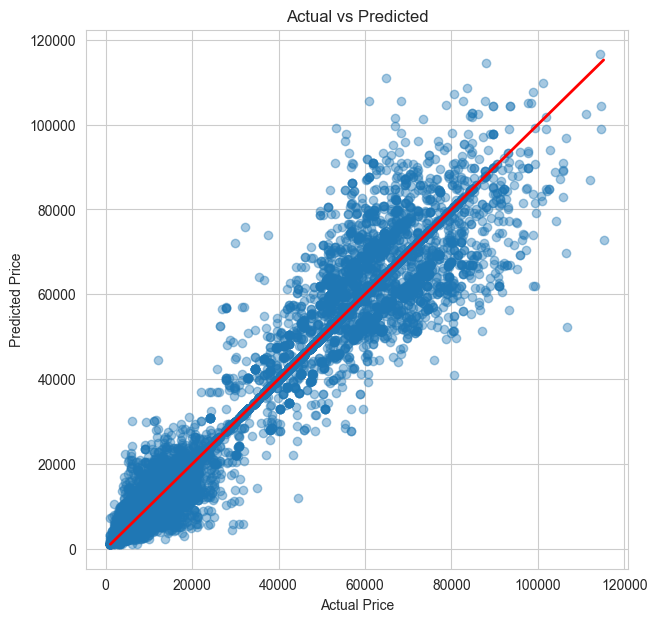

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.4
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

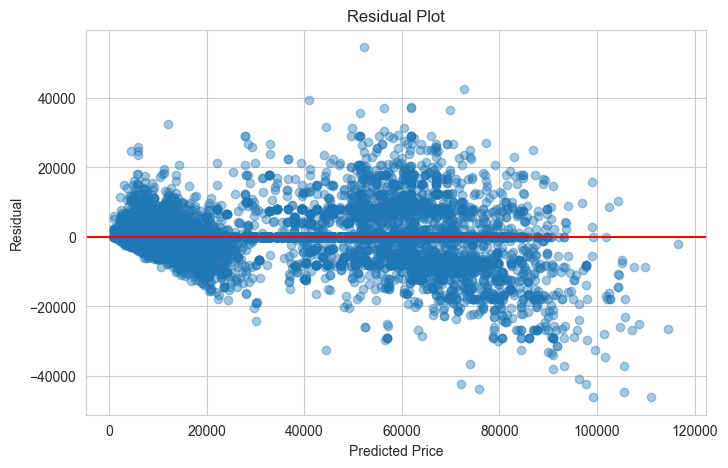

In [55]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8,5))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.4
)

plt.axhline(
    0,
    color="red"
)

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

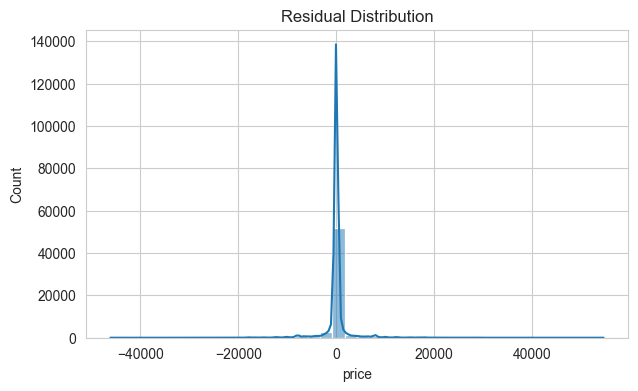

In [56]:
import seaborn as sns

plt.figure(figsize=(7,4))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

In [57]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": dt.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
1589,class_Economy,0.879562
0,duration,0.048056
1,days_left,0.018064
6,airline_Vistara,0.009540
1585,destination_city_Delhi,0.004041
1568,source_city_Delhi,0.003688
1571,source_city_Mumbai,0.002336
1588,destination_city_Mumbai,0.002098
1586,destination_city_Hyderabad,0.001964
1570,source_city_Kolkata,0.001692


In [58]:
print("Tree Depth :", dt.get_depth())

print("Number of Leaves :", dt.get_n_leaves()) 

Tree Depth : 96
Number of Leaves : 81328


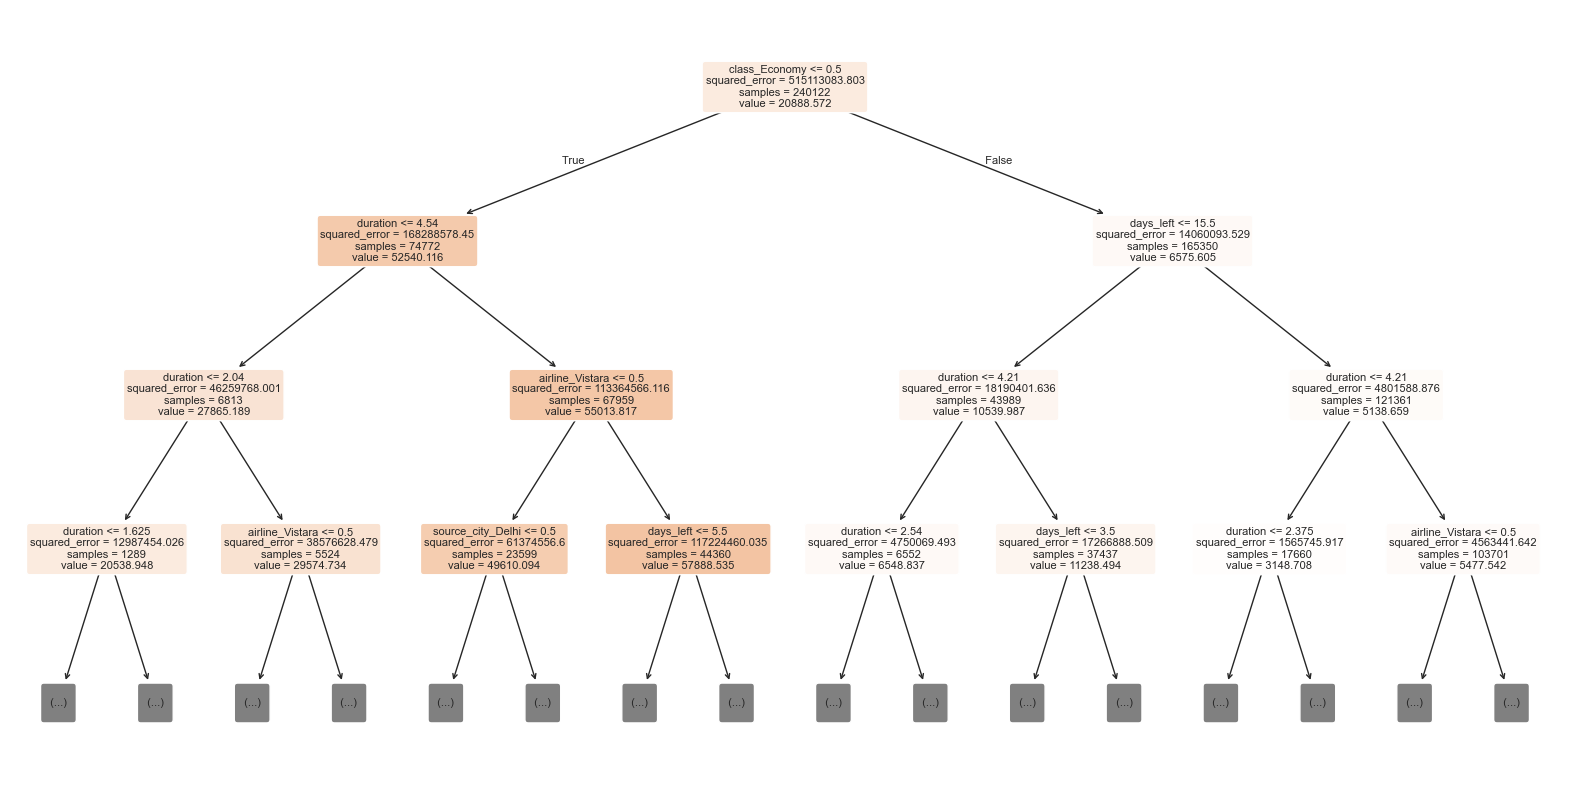

In [59]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    max_depth=3,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [60]:
sample = X_test.iloc[[0]]

prediction = dt.predict(sample)

print("Predicted Price:", prediction[0])

print("Actual Price:", y_test.iloc[0])

Predicted Price: 7366.0
Actual Price: 7366


In [61]:
import joblib

joblib.dump(dt, "flight_price_decision_tree_regressor.pkl") 

['flight_price_decision_tree_regressor.pkl']

In [62]:
model = joblib.load("flight_price_decision_tree_regressor.pkl")

## **Hyperparameter Tuning & Pruning**

In [63]:
DecisionTreeRegressor(random_state=42)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [64]:
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.tree import DecisionTreeRegressor

In [65]:
dt1 = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

dt1.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [66]:
param_grid = {

    "max_depth": [5, 10, 15, 20, None],

    "min_samples_split": [2, 5, 10, 20],

    "min_samples_leaf": [1, 2, 5, 10],

    "max_features": [
        None,
        "sqrt",
        "log2"
    ]
}

In [67]:
grid = GridSearchCV(

    estimator=DecisionTreeRegressor(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1,

    verbose=2
)

In [ ]:
grid.fit(X_train, y_train)

In [ ]:
print(grid.best_params_)

In [ ]:
print(grid.best_score_)

In [ ]:
best_tree = grid.best_estimator_

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("Training")

print("MAE:",
      mean_absolute_error(
          y_train,
          train_pred
      ))

print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_train,
              train_pred
          )
      ))

print("R²:",
      r2_score(
          y_train,
          train_pred
      ))

In [ ]:
print("Testing")

print("MAE:",
      mean_absolute_error(
          y_test,
          test_pred
      ))

print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test,
              test_pred
          )
      ))

print("R²:",
      r2_score(
          y_test,
          test_pred
      ))

In [ ]:
param_dist = {

    "max_depth": [
        None,
        5,
        10,
        15,
        20,
        25,
        30
    ],

    "min_samples_split": [
        2,
        5,
        10,
        20
    ],

    "min_samples_leaf": [
        1,
        2,
        5,
        10
    ],

    "max_features": [
        None,
        "sqrt",
        "log2"
    ]
}

In [ ]:
random = RandomizedSearchCV(

    estimator=DecisionTreeRegressor(
        random_state=42
    ),

    param_distributions=param_dist,

    n_iter=20,

    cv=5,

    scoring="r2",

    random_state=42,

    n_jobs=-1,

    verbose=2
)

In [ ]:
random.fit(
    X_train,
    y_train
)

In [ ]:
print(random.best_params_)

In [ ]:
path = best_tree.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas

In [ ]:
ccp_alphas[:10]

In [ ]:
trees = []

for alpha in ccp_alphas:

    model = DecisionTreeRegressor(

        random_state=42,

        ccp_alpha=alpha

    )

    model.fit(
        X_train,
        y_train
    )

    trees.append(model)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    ccp_alphas,
    train_scores,
    label="Train R²"
)

plt.plot(
    ccp_alphas,
    test_scores,
    label="Test R²"
)

plt.xlabel("CCP Alpha")

plt.ylabel("R²")

plt.legend()

plt.title("Cost Complexity Pruning")

plt.show()

In [ ]:
best_alpha = 0.01

final_tree = DecisionTreeRegressor(

    random_state=42,

    ccp_alpha=best_alpha
)

final_tree.fit(
    X_train,
    y_train
)

In [ ]:
pred = final_tree.predict(X_test)

print("MAE:",
      mean_absolute_error(
          y_test,
          pred
      ))

print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test,
              pred
          )
      ))

print("R²:",
      r2_score(
          y_test,
          pred
      ))

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_tree.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show() 

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    final_tree,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=3
)

plt.show() 

In [ ]:
y_pred = final_tree.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10) 

In [ ]:
sample = X_test.iloc[[0]]

prediction = final_tree.predict(sample)

print("Predicted Price:", prediction[0])
print("Actual Price   :", y_test.iloc[0]) 

In [ ]:
import joblib

joblib.dump(final_tree, "flight_price_decision_tree.pkl") 

In [ ]:
prediction = model.predict(sample)

print(prediction) 